<a href="https://colab.research.google.com/github/GuilleLondero/challenge-one-data-science/blob/main/ExtraAluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [3]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. ¡Extra! Análisis del desempeño geográfico:
  
   




1.1 Gráfico de dispersión de ventas geolocalizadas:


<ipython-input-5-46007e4a688d>:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


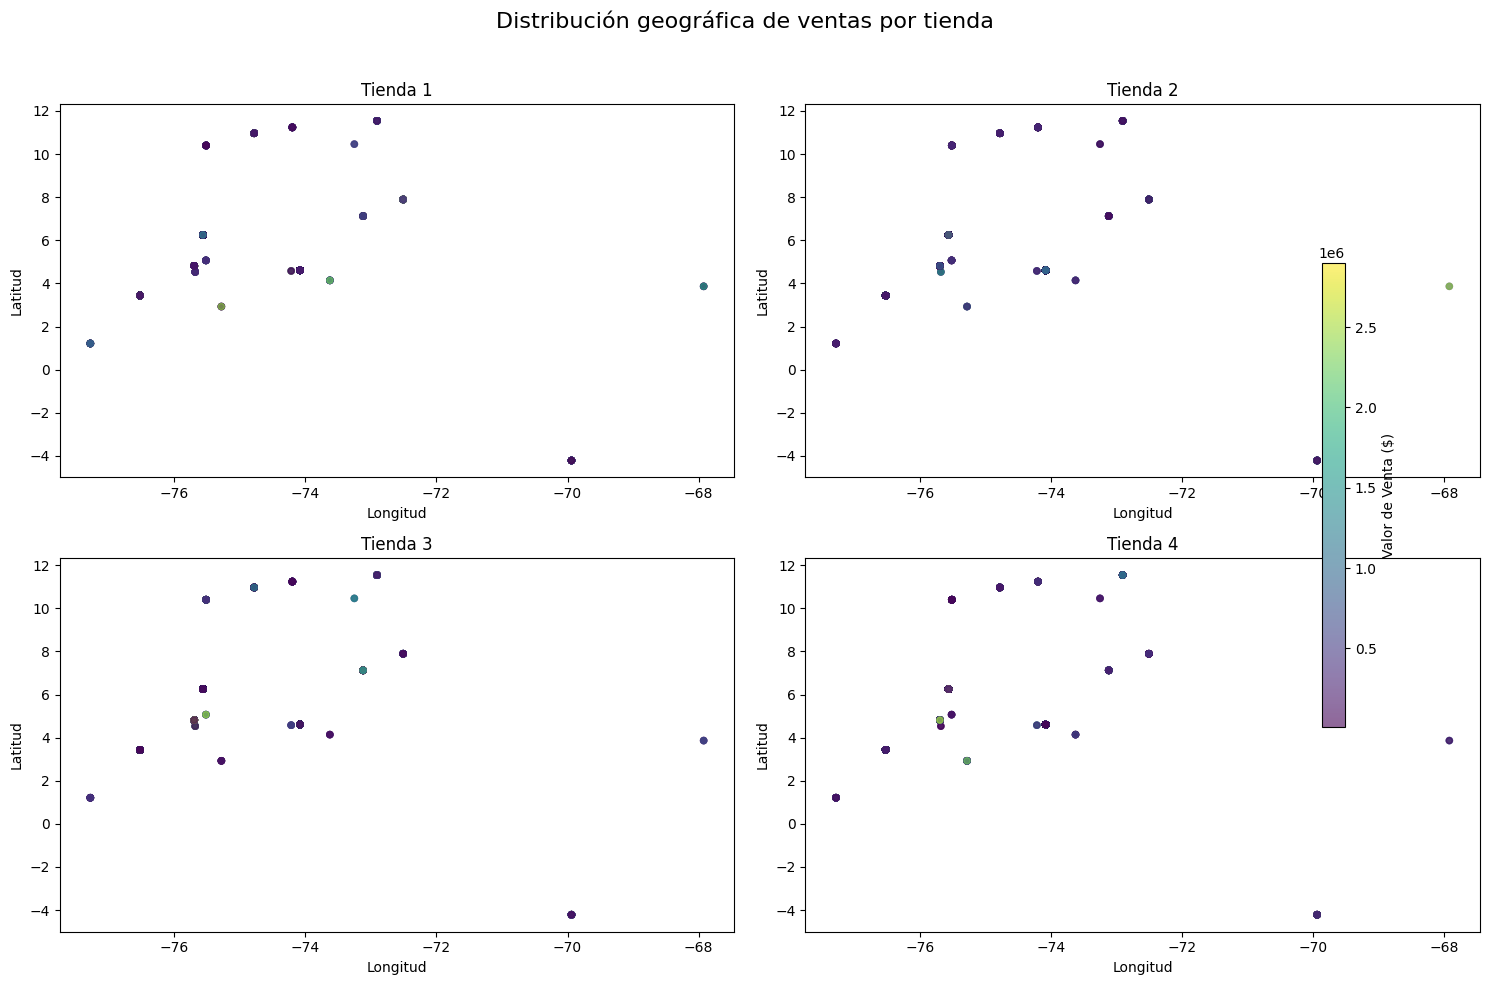

1.2 mapa interactivo con Folium:

In [6]:
!pip install folium


In [8]:
import folium
from folium.plugins import MarkerCluster

# Paso 1: Calcular el centro del mapa con el promedio de latitud y longitud
lat_prom = tienda1['lat'].mean()
lon_prom = tienda1['lon'].mean()

# Paso 2: Crear el mapa base centrado en la tienda 1
mapa_tienda1 = folium.Map(location=[lat_prom, lon_prom], zoom_start=6, tiles='CartoDB positron')

# Paso 3: Crear un agrupador de marcadores para evitar superposición
marcadores = MarkerCluster().add_to(mapa_tienda1)

# Paso 4: Agregar un marcador por cada venta
for _, fila in tienda1.iterrows():
    folium.Marker(
        location=[fila['lat'], fila['lon']],
        popup=f"Venta: ${fila['Precio']:.2f}\nCalificación: {fila['Calificación']}",
        icon=folium.Icon(color='blue', icon='shopping-cart', prefix='fa')
    ).add_to(marcadores)

# Paso 5: Mostrar el mapa
mapa_tienda1
